<a href="https://colab.research.google.com/github/nicolevillagrana2/Sprint-7/blob/main/sprint7-final-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(10)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
5,10005,Luis,Garcia,61,MTY,2022-01-02 08:51:29.572393098,Basico,NaN
6,10006,Sofia,Lopez,39,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN
7,10007,Sofia,Gomez,70,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN
8,10008,Sofia,Garcia,76,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN
9,10009,Mateo,Torres,47,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print('users', users.isna().sum())
print('users', users.isna().mean())


users user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
users user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print('usage', usage.isna().sum())
print('usage', usage.isna().mean())


usage id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
usage id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? Las columnas churn__date y city tienen valores nulos pero en una proporción considerablemente diferente, en este caso churn_date tiene una proporción del 88% de valores nulos la cual la hace bastante grande a comparación de la columna city que solamente cuenta con el 11%
- Indica qué harías: ¿imputar, eliminar, ignorar?
En el caso de churn_date, es preferible eliminarlo (drop) ya que solamente traería una alteración para el análisis al tener una gran cantidad de valores nulos.
Por el contrario, city solamente cuenta con el 11% de valores nulos, siendo posible solo convertilos a "null" ya que al ser muy pocos los datos que no se encuentran, no afectaria de gran manera el análisis correspondiente.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ... A comparación de la columna user_id, age tiene varias inconsistencias, tales como la edad mínima siendo -999 y el promedio siendo diferente a la mediana

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ... `id` y `user_id' son muy diferentes, a pesar de tener la misma cantidad de elementos el mínimo de id es 1, mientras que el de user_id es 10000, alterando también su máximo. A pesar de esto la mediana y el promedio son muy cercanos más entre si, son completamente diferentes.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` ... muestra la falta de valores (el 11% antes mencionado) desde la columna count
- La columna `plan` ... se aprecia cuál es el tipo de plan más elegido por la población y con qué frecuencia del total se ha utilizado

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` ... nos demuestra cuantos tipos de categorías hay en usage, en este caso existen solamente 2 siendo text la más utilizada con frequencia de 22092 dentro de todo el documento siendo que las personas prefieren mandar mensajes que tomar una llamada


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? en este caso solamente encontré valores inválidos dentro de 'city'.
- ¿Qué acción tomarías? En este caso se toma la decisión de dejar los valores nulos o reemplazarlos por "null" ya que al ser una pequeña cantidad de valores no afecta en el análisis

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = 'coerce', utc = True)
users['reg_date'].dtype

datetime64[ns, UTC]

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = 'coerce', utc = True)
usage['date'].dtype

datetime64[ns, UTC]

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Se puede apreciar que no se encuentran en un orden específico los años y aparece el año 2026, el cual no debería de aparecer ya que el análisis es hasta el año 2024

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
Solamente se puede apreciar el año 2024, dentro de este archivo es el único que se encuentra

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Si, aparecen años sin transcurrir en este caso el año 2026, en este caso al aparecer muy pocas veces (40), solamente lo transformaría a 'null'

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', 'pd.NA')

# Verificar cambios
users['city'].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'])
users['reg_date'] = users['reg_date'].dt.year.replace(2026, pd.NA).astype('Int64')
users['reg_date'].describe()

count    3960.000000
mean     2023.004040
std         0.817208
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2024.000000
Name: reg_date, dtype: float64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Si, se considera que es MAR ya que la variable 'type' es la estudiada en este caso, los mensajes no tienen duración ni las llamadas longitud por lo que no falta información, más bien "no aplica"

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)#conocer el total de llamadas
usage["total_min"] = usage["duration"].where(usage["type"] == "call", 0)


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','total_min']].sum().reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,total_min
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns = {'is_text':'cant_mensajes','is_call':'cant_llamadas','total_min':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_merge = users.merge(usage_agg,on=['user_id'], how = 'left')
user_merge.head(5)
print(user_merge.columns.tolist())


['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_merge.describe()

,user_id,age,reg_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3960.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,2023.004040,5.524381,4.478120,22.836934
std,1154.844867,17.690408,0.817208,2.358416,2.144238,16.590213
min,10000.000000,18.000000,2022.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,2022.000000,4.000000,3.000000,11.095000
50%,11999.500000,47.000000,2023.000000,5.000000,4.000000,19.740000
75%,12999.250000,63.000000,2024.000000,7.000000,6.000000,31.185000
max,13999.000000,79.000000,2024.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan

plan_dist = (users['plan']).value_counts(normalize = True)
print(plan_dist)


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

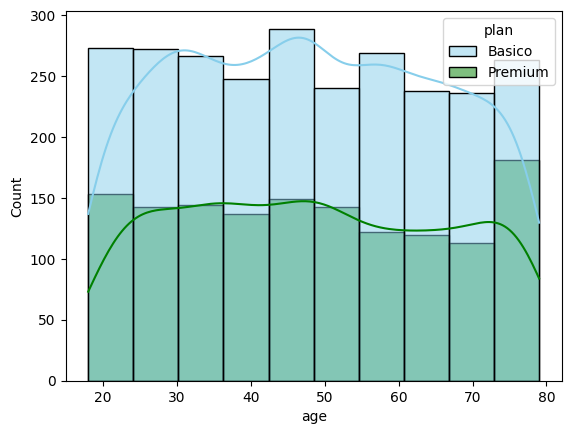

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data = user_merge ,x ='age', hue='plan', bins = 10, palette=['skyblue','green'], kde=True)
plt.show()

💡Insights:
- Distribución ...

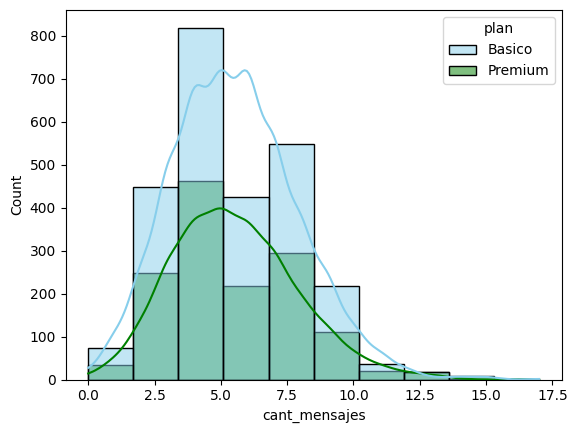

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data = user_profile,x ='cant_mensajes', hue='plan', bins = 10, palette=['skyblue','green'], kde=True)
plt.show()


💡Insights:
- ....

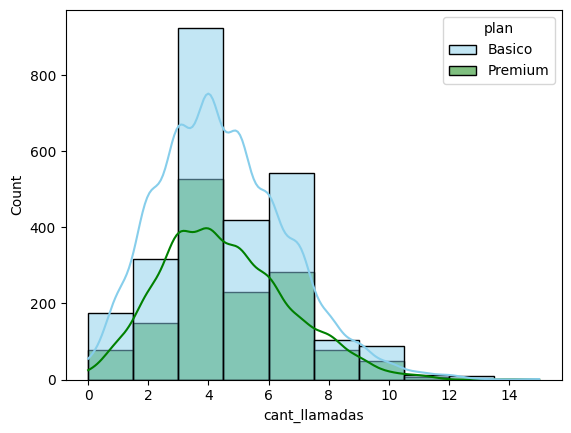

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data = user_profile,x ='cant_llamadas', hue='plan', bins = 10, palette=['skyblue','green'], kde=True)
plt.show()

💡Insights:
- Distribución ...

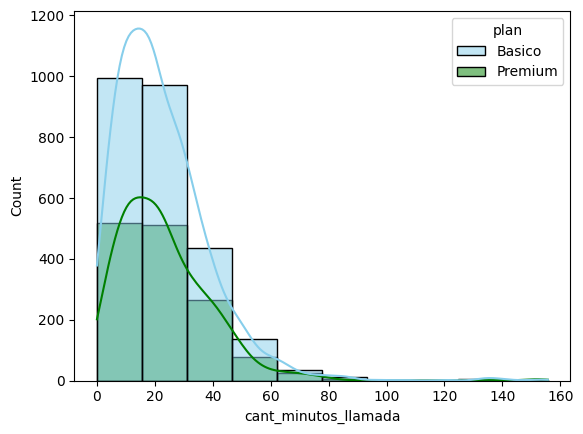

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile,x ='cant_minutos_llamada', hue='plan', bins = 10, palette=['skyblue','green'], kde=True)
plt.show()

💡Insights:
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

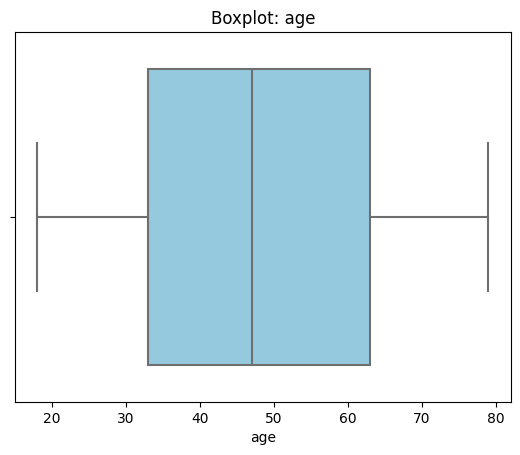

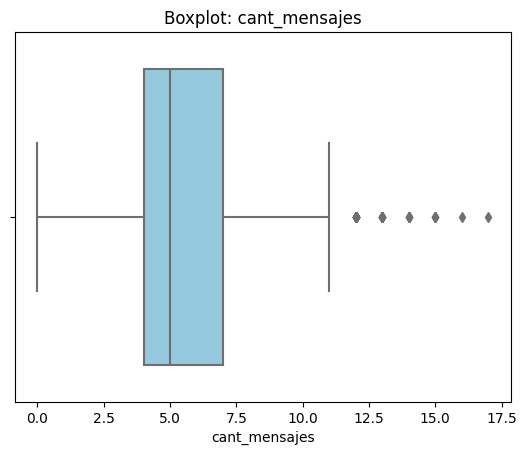

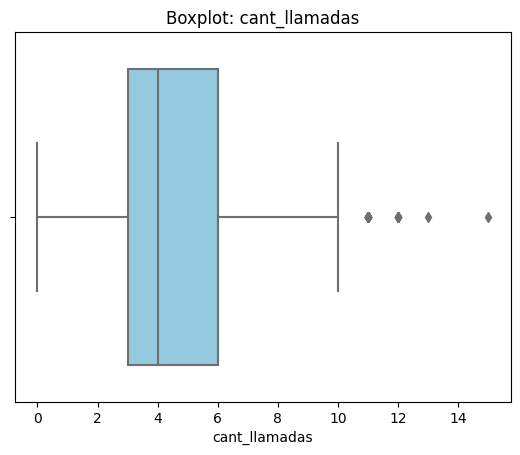

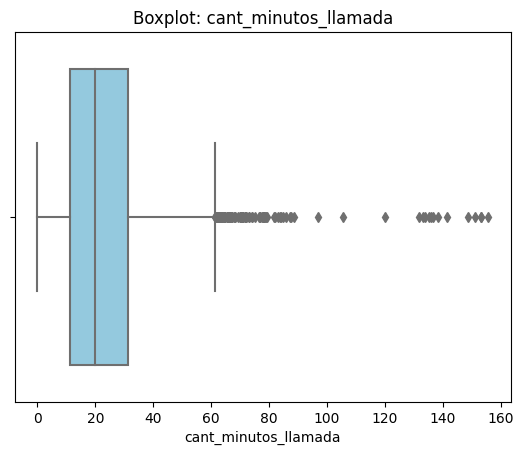

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_merge[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: ...No presenta outliers, se puede apreciar la mediana cerca del 50
- cant_mensajes: ... La media apreciada en el boxplot nos da a entender que más del 50% de los usuarios mandaron 5 o más mensajes,  y que el otro porcentaje mandó 5 o menos mensajes. Se muestra que si hubo algún usuario que mandó más mensajes que el promedio entre 12 y 17 siendo pocos los outliers
- cant_llamadas: ... En este caso la mediana apreciada se encuentra en 4 llamadas, estando las demás partes de la caja entre 3 y 6 llamadas siendo que la mayoría de usuarios toma esta cantidad de llamadas. Se encuentran outliers en los que se puede apreciar los usuarios que toman más llamadas entre 11 y 15 llamadas.
- cant_minutos_llamada: ... La mediana se encuentra en aprox. 20min de llamada con la mayoría de los usuarios tomando entre 10 y 30 minutos de llamadas. Se encuentran varios outliers la mayoría entre 60 y 90min siendo que muchos usuarios toman esta cantidad de llamadas

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    q1 = user_merge[col].quantile(0.25)
    q3 = user_merge[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    print(f'\nColumna: {col}')
    print('Límite inferior: ', lower)
    print('Límite superior: ', upper)





Columna: cant_mensajes
Límite inferior:  -0.5
Límite superior:  11.5

Columna: cant_llamadas
Límite inferior:  -1.5
Límite superior:  10.5

Columna: cant_minutos_llamada
Límite inferior:  -19.04
Límite superior:  61.31999999999999


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_merge[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Si, en este caso la cantidad de usuarios que representan esos outliers son pocos, los cuales al ser pocos outliers podrían ser datos importantes para el análisis.
- cant_llamadas: mantener o no outliers, porqué? Mantenerlos, esto gracias a que son pocos outliers y no alteran de gran manera los datos para el análisis
- cant_minutos_llamada: mantener o no outliers, porqué? No, en este caso no debería de mantenerse esta cantidad de outliers ya que afectan demasiado la mediana y pueden afectar los resultados del análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_merge['grupo_uso'] = (
    (user_merge['cant_llamadas']< 5) &
    (user_merge['cant_mensajes']< 5)
)

In [ ]:
# verificar cambios
user_merge.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,z,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,0.052023,False
1,10001,Mateo,Torres,53.0,pd.NA,2022,Basico,NaN,5.0,10.0,33.18,0.623444,False
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,-0.729161,False
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,-0.834645,False
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,-0.893716,True


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_merge["grupo_edad"] = np.where(
        user_merge['age']<30 , 'Joven',
                np.where(user_merge['age'] < 60,'Adulto', 'Adulto Mayor')
    )


In [ ]:
# verificar cambios
user_merge.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,z,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,7.0,3.0,23.70,0.052023,False,Adulto
1,10001,Mateo,Torres,53.0,pd.NA,2022,Basico,NaN,5.0,10.0,33.18,0.623444,False,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,5.0,2.0,10.74,-0.729161,False,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,11.0,3.0,8.99,-0.834645,False,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,4.0,3.0,8.01,-0.893716,True,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

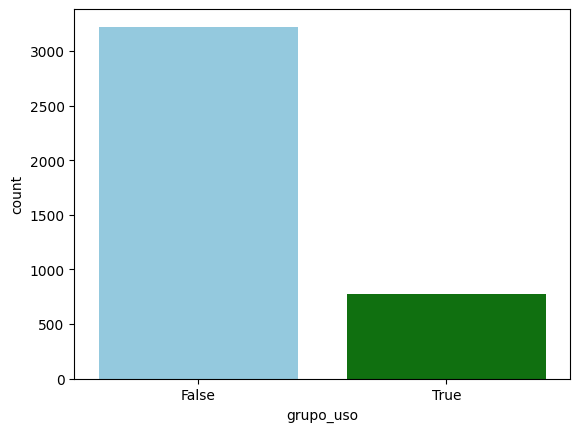

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data = user_merge, x ='grupo_uso', palette=['skyblue','green'])

plt.show()


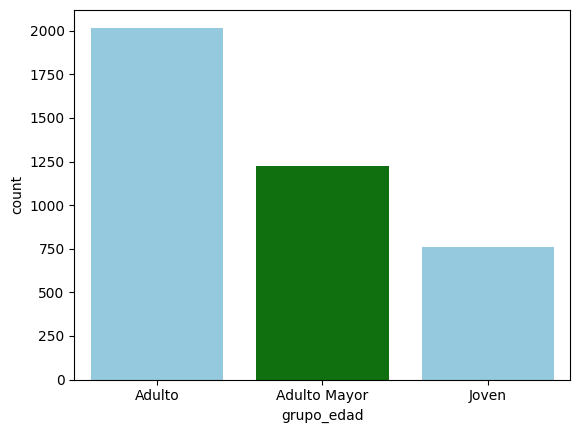

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data = user_merge, x ='grupo_edad', palette=['skyblue','green'])

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Los datos de las columnas churn_date tiene una gran cantidad de valores nulos con una proporción del 88%, en esta misma base de datos la columna city siendo que esta solamente presentó el 11%. En este caso se toma la decisión de "drop" ya que solamente traería una alteración para el análisis de los datos, en el caso de city solamente se convierte a null

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se encuentra una mediana entre 45 y 50 años, siendo que la mayoría de clientes se encuentran en este rango más no se encuentran outliers, y en los bigotes se puede apreciar que el rango de edad en los clientes llega desde los 20 a 80 años enfocándose más entre los 30 y 60 años
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
Los segmentos más valiosos podría ser la cantidad de llamadas en lugar de los minutos por llamada o la cantidad de mensajes, ya que es en esta área que existen menos outliers
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
se encuentran outliers en la cantidad de llamadas y cantidad de mensajes, los cuales expresan que hay varios usuarios que toman más de lo normal. En el caso del tiempo de las llamadas al ser todas de una duración diferente si se encuentran demasiados outliers los que expresan que siempre hay muchas llamadas con más tiempo fuera de la media.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Recomendaría enfocar el mercado a las edades de 30 a 60 años para elevar las ventas, y de ser posible enfocar ofertas en las llamadas ya que es lo más usado dentro de la media además de probablemente agregar cargos a las llamadas de mayor duración ya que hay muchas llamadas que duran más de 90min
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- 88% en churn_date
- 11% en city


🔍 **Segmentos por Edad**
- Adulto
- Joven
- Adulto mayor


📊 **Segmentos por Nivel de Uso**
- True (usuarios con bajo uso o <5 llamadas/mensajes)
- False(usuarios con >5 llamadas o mensajes)


➡️ Esto sugiere que ... Menos de 1000 usuarios mandan menos de 5 llamadas o mensajes



💡 **Recomendaciones**
- Se recomienda que se enfoquen las ofertas o cargos en la cantidad de llamadas o mensajes
- Se recomienda un mayor enfoque dentro de los adultos, ya que es el mercado más grande

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`